# 03 — Volatility Forecasting (LSTM 학습·앙상블 통합 노트북)

> Phase 1.5 LSTM v4 + HAR-RV 베이스라인 + Performance-Weighted Ensemble (Diebold-Pauly 1987) 의
> **단독 완결 노트북** — 학습·앙상블·검증·BL 재계산까지 final/ 안에서 모두 수행.

## 본 노트북의 두 모드

**Mode A — Cache hit (default, 빠른 검증)**: 기존 ensemble csv 를 로드하여 §1 정합성 + §6 시각화 + §7 검증.

**Mode B — Full retraining (FORCE_RECOMPUTE=True, GPU 1.5~3시간)**:
- §1.5 daily_panel 빌드 (final/data → long format)
- §2 LSTM v4 모델 구조
- §3 HAR-RV 베이스라인
- §4 walk-forward + Performance ensemble (final/lstm_pipeline.run_ensemble_for_universe_parallel)
- §5 ensemble 결과 final/phase3 자동 저장
- §6 615 종목 평가 + 시각화
- §7 BL 156 pkl 의 12월 시점 자동 재계산 (subprocess _extend_bl_to_2025.py --recompute-2025)
- §8 종합 검증

## 의존 모듈

- **`final/timeseries_lib.py`** — low-level 함수 (LSTMRegressor, train_one_fold, fit_har_rv, walk_forward_folds, build_fold_inputs)
- **`final/lstm_pipeline.py`** — high-level orchestration (build_daily_panel, build_v4_inputs, run_walkforward_for_ticker, compute_performance_weights, run_ensemble_for_universe_parallel)

## final/data/ 의존 데이터

- `daily_returns.pkl` (2026-03-30 까지)
- `macro_daily.csv` (vix 컬럼 포함, 2026-03-30 까지)
- `universe.csv` (LSTM 학습 universe)
- `sp500_membership.pkl` (생존편향)

## 모드

- **snapshot 모드** (현재 csv 가 5월 초 원본): byte-byte 동등 검증
- **재학습 후 모드** (FORCE_RECOMPUTE=True 후): 구조 검증, RMSE 차이 표시

## §0. 환경 설정

In [1]:
import sys
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore', category=FutureWarning)

# timeseries_lib import
sys.path.insert(0, str(Path.cwd()))
import timeseries_lib as tlib

# 시드·폰트 고정
tlib.setup_seeds(42)
tlib.setup_korean_font()

# 경로
DATA_DIR = Path('phase3(data_outputs)/data')
PANEL_DIR = Path('data')
OUT_DIR = Path('outputs/03_volatility')
OUT_DIR.mkdir(parents=True, exist_ok=True)

# 캐시 모드
FORCE_RECOMPUTE = True  # True 시 615 종목 LSTM 재학습 (GPU + 3~5시간, Phase 1.5 모듈 필요)

print(f"DATA_DIR: {DATA_DIR.resolve()}")
print(f"OUT_DIR : {OUT_DIR.resolve()}")
print(f"FORCE_RECOMPUTE: {FORCE_RECOMPUTE}")

DATA_DIR: C:\Users\gorhk\최종 프로젝트\finance_project\final\phase3(data_outputs)\data
OUT_DIR : C:\Users\gorhk\최종 프로젝트\finance_project\final\outputs\03_volatility
FORCE_RECOMPUTE: True


## §1. CSV 데이터 정합성 검증 ⚠️

`final/phase3(data_outputs)/data/ensemble_predictions_stockwise.csv` 가 초기 학습 결과 (snapshot) 와 정확히 일치하는지 검증합니다.

**검증 항목**:
1. md5 hash 일치 (초기 학습 결과와 byte-byte 동일)
2. row / column / 종목 수 / 날짜 범위
3. y_true 의 -inf 행 제거 (거래정지 등)
4. 615 종목 stockwise 환경 RMSE 평균 (LSTM 0.43±, HAR 0.39±, Ensemble 0.38±)

In [2]:
import hashlib

CSV_PATH = DATA_DIR / 'ensemble_predictions_stockwise.csv'

# 1.1 md5 hash 검증 (snapshot vs post-retrain 자동 분기)
print("§1.1 md5 hash 검증")
print("-" * 60)
with open(CSV_PATH, 'rb') as f:
    md5 = hashlib.md5(f.read()).hexdigest()
print(f"current md5: {md5}")

# 초기 학습 결과 (2026-05-01 빌드) 의 md5 — 5월 초 panel cutoff 시점
SNAPSHOT_MD5 = '1e9ab2faf63fdfd4abbb54083a1cb0fb'

# 02a_retrain_2025_12 노트북으로 재학습한 경우 md5 가 다름 — 정상
if md5 == SNAPSHOT_MD5:
    print(f"  ✓ snapshot 일치 (초기 학습 결과) — byte-byte 동등")
    SNAPSHOT_MODE = True
else:
    print(f"  ⚠ snapshot 와 다름 (재학습 후 갱신된 csv)")
    print(f"     - snapshot md5 : {SNAPSHOT_MD5}")
    print(f"     - current md5  : {md5}")
    print(f"  → 재학습 후 갱신본 검증 모드로 진행 (구조·범위 검증, byte 비교 skip)")
    SNAPSHOT_MODE = False

§1.1 md5 hash 검증
------------------------------------------------------------
current md5: 5d132bc691c09fbecc2d0b7191b4191a
  ⚠ snapshot 와 다름 (재학습 후 갱신된 csv)
     - snapshot md5 : 1e9ab2faf63fdfd4abbb54083a1cb0fb
     - current md5  : 5d132bc691c09fbecc2d0b7191b4191a
  → 재학습 후 갱신본 검증 모드로 진행 (구조·범위 검증, byte 비교 skip)


In [3]:
# 1.2 데이터 로드 + 기본 정제 (-inf 제거)
print()
print('§1.2 데이터 로드')
print('-' * 60)
df = tlib.load_ensemble_predictions(CSV_PATH)

# 1.3 구조 검증
print()
print('§1.3 구조 검증')
print('-' * 60)
print(f'  shape: {df.shape}')
print(f'  columns: {list(df.columns)}')
print(f'  종목 수: {df["ticker"].nunique()}')
print(f'  date 범위: {df["date"].min().date()} ~ {df["date"].max().date()}')
print(f'  fold 수: {df["fold"].nunique()}')

n_tickers = df['ticker'].nunique()
assert 600 <= n_tickers <= 625, f'종목 수 비정상: {n_tickers} (예상 600~625)'
assert {'date','ticker','fold','y_true','y_pred_lstm','y_pred_har',
        'w_v4','w_har','y_pred_ensemble'}.issubset(df.columns), '컬럼 누락'
if SNAPSHOT_MODE:
    assert n_tickers == 613, f'snapshot 모드: 종목 수 불일치 ({n_tickers} != 613)'
    print(f'  ✓ snapshot 일치: 613 종목')
else:
    print(f'  ✓ 재학습 후 모드: {n_tickers} 종목 (600~625 정상 범위)')

# 데이터 cover 검증
date_max = df['date'].max()
print()
print(f'  최신 학습 데이터: {date_max.date()}')
if SNAPSHOT_MODE:
    print(f'  → snapshot: 2025-12-01 (12월 1일치) 만 cover')
else:
    print(f'  → 재학습 후: 2025-12 ~ 2026-04 forward 21d 부재 직전까지 cover 가능')



§1.2 데이터 로드
------------------------------------------------------------
ensemble_predictions 로드: 2,456,558 → 2,456,531 행 (-inf/NaN 27 행 제거)

§1.3 구조 검증
------------------------------------------------------------
  shape: (2456531, 9)
  columns: ['date', 'ticker', 'fold', 'y_true', 'y_pred_lstm', 'y_pred_har', 'w_v4', 'w_har', 'y_pred_ensemble']
  종목 수: 614
  date 범위: 2007-04-23 ~ 2025-12-29
  fold 수: 221
  ✓ 재학습 후 모드: 614 종목 (600~625 정상 범위)

  최신 학습 데이터: 2025-12-29
  → 재학습 후: 2025-12 ~ 2026-04 forward 21d 부재 직전까지 cover 가능


In [4]:
# 1.4 615 종목 평균 RMSE 검증 (Phase 3-2 §2-B 기준)
print()
print("§1.4 615 종목 평균 RMSE 검증")
print("-" * 60)
rmse_full = df.groupby('ticker', group_keys=False).apply(
    lambda x: pd.Series({
        'lstm': tlib.rmse(x['y_true'].values, x['y_pred_lstm'].values),
        'har': tlib.rmse(x['y_true'].values, x['y_pred_har'].values),
        'ens': tlib.rmse(x['y_true'].values, x['y_pred_ensemble'].values),
    }),
    include_groups=False,
)
print(f"  LSTM avg RMSE:     {rmse_full['lstm'].mean():.4f}")
print(f"  HAR  avg RMSE:     {rmse_full['har'].mean():.4f}")
print(f"  Ensemble avg RMSE: {rmse_full['ens'].mean():.4f}")
print()
print(f"  Best model 분포 (모델별 best 종목 수):")
best_per_ticker = rmse_full.idxmin(axis=1).value_counts()
for model, n in best_per_ticker.items():
    print(f"    {model}: {n} 종목 ({n/len(rmse_full)*100:.1f}%)")


§1.4 615 종목 평균 RMSE 검증
------------------------------------------------------------
  LSTM avg RMSE:     0.5211
  HAR  avg RMSE:     0.3919
  Ensemble avg RMSE: 0.3825

  Best model 분포 (모델별 best 종목 수):
    ens: 401 종목 (65.3%)
    har: 199 종목 (32.4%)
    lstm: 14 종목 (2.3%)


In [5]:
# 1.5 Universe 호환성 (final/data/universe.csv 와 교집합)
print()
print("§1.5 Universe 호환성")
print("-" * 60)
universe = pd.read_csv(PANEL_DIR / 'universe.csv')
print(f"  final/universe.csv 종목 수: {universe['ticker'].nunique()}")
ens_tickers = set(df['ticker'].unique())
uni_tickers = set(universe['ticker'].unique())
print(f"  ensemble 종목 수: {len(ens_tickers)}")
print(f"  교집합: {len(ens_tickers & uni_tickers)}")
assert ens_tickers.issubset(uni_tickers), "ensemble 종목이 final universe 에 부분집합 아님"
print("  ✓ ensemble 613 종목 ⊂ final universe 833 (완벽 부분집합)")


§1.5 Universe 호환성
------------------------------------------------------------
  final/universe.csv 종목 수: 833
  ensemble 종목 수: 614
  교집합: 614
  ✓ ensemble 613 종목 ⊂ final universe 833 (완벽 부분집합)


## §2. LSTM v4 모델 구축

Phase 1.5 v4 best 아키텍처 (3ch_vix / IS=1250 / hidden=32 / dropout=0.3) 를 정의합니다.
파라미터 수 ≈ 4,769 (입력 3채널 기준).

In [6]:
# §2.1 모델 인스턴스 + 파라미터 카운트
print("§2.1 LSTM v4 best 아키텍처")
print("-" * 60)
model = tlib.LSTMRegressor(input_size=3, hidden_size=32, num_layers=1, dropout=0.3)
n_params = tlib.count_parameters(model)
print(model)
print(f"\nParameter count: {n_params:,}")
assert 4500 < n_params < 5000, f"parameter count 비정상: {n_params}"
print(f"  ✓ 예상 범위 4,500~5,000 충족")

§2.1 LSTM v4 best 아키텍처
------------------------------------------------------------
LSTMRegressor(
  (lstm): LSTM(3, 32, batch_first=True)
  (head_dropout): Dropout(p=0.3, inplace=False)
  (head): Linear(in_features=32, out_features=1, bias=True)
)

Parameter count: 4,769
  ✓ 예상 범위 4,500~5,000 충족


## §3. HAR-RV 베이스라인 (Corsi 2009)

```
log(RV_h[t+h]) = β₀ + β_d·log(RV_d[t]) + β_w·log(RV_w[t]) + β_m·log(RV_m[t])
```

Heterogeneous Market Hypothesis (Müller et al. 1997) 의 일별·주별·월별 다중 시간대 평균.
Walk-Forward 환경에서 train_idx 만으로 OLS 적합.

In [7]:
# §3.1 HAR-RV 함수 시그니처 확인
print("§3.1 HAR-RV — fit_har_rv 시그니처")
print("-" * 60)
help(tlib.fit_har_rv)

§3.1 HAR-RV — fit_har_rv 시그니처
------------------------------------------------------------
Help on function fit_har_rv in module timeseries_lib:

fit_har_rv(log_ret: 'pd.Series', train_idx: 'np.ndarray', test_idx: 'np.ndarray', horizon: 'int' = 21, eps: 'float' = 1e-12) -> 'Tuple[np.ndarray, Dict[str, float]]'
    HAR-RV (Heterogeneous Autoregressive Realized Volatility).

    log(RV_h[t+h]) = β₀ + β_d·log(RV_d[t]) + β_w·log(RV_w[t]) + β_m·log(RV_m[t])

    Variance proxy (일간 데이터 적응):
        RV_var_d[t] = log_ret[t]²
        RV_var_w[t] = mean(log_ret²[t-4 : t+1])
        RV_var_m[t] = mean(log_ret²[t-21 : t+1])



## §4. Walk-Forward 학습 (cache hit 우선)

본 셀은 `FORCE_RECOMPUTE` 플래그에 따라 동작이 다릅니다.

| FORCE_RECOMPUTE | 동작 | 소요 시간 |
|---|---|---|
| `False` (기본) | `ensemble_predictions_stockwise.csv` cache hit → 즉시 결과 | ~5 초 |
| `True` | 615 종목 × 90 fold 풀 재학습 (Phase 1.5 모듈 의존) | GPU + 3~5 시간 |

In [8]:
# §4.1 Walk-Forward 학습 — Cache hit OR Full retraining
print('§4.1 Walk-Forward 학습')
print('-' * 60)

if FORCE_RECOMPUTE:
    print('⚠️  FORCE_RECOMPUTE=True — 캐시 점검 + 결손 부분만 재학습')
    print('   Universe 정책: final/data 의 daily_returns + universe.csv 기준')
    print()

    # GPU 확인
    import torch
    if not torch.cuda.is_available():
        print('⚠ CUDA 미가용 — CPU 학습 ~5시간 (GPU 권장)')
        device = 'cpu'
    else:
        device = 'cuda'
        print(f'✅ GPU 가용: {torch.cuda.get_device_name(0)}')
        print(f'   memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

    # 1. lstm_pipeline import
    import lstm_pipeline as lp

    # 2. daily_panel 빌드 (final/data → long format, final 기준)
    # 학습 시간 단축: BL 분석 기간 2025-12-31 까지에 맞춰 panel 끝점 cap
    # → LSTM walk_forward 가 자동으로 fold 224 (12-31 OOS) 까지만 생성, fold 225-226 skip
    PANEL_MAX_DATE = '2026-04-30'   # fold 222~226 cover 위해 충분히 길게 (2026-04-30)

    print()
    print('§4.2 daily_panel 빌드 (final/data → long format)')
    print('-' * 60)
    print(f'  panel max_date: {PANEL_MAX_DATE} (BL 분석 기간 2025-12-31 + 21d buffer)')

    PANEL_LONG_PATH = DATA_DIR / 'daily_panel_long.csv'
    # cache 검증 — max_date + start_date 모두 일치해야 cache hit
    # (daily_returns.pkl 가 갱신된 경우 cache 자동 무효화)
    panel_needs_rebuild = True
    if PANEL_LONG_PATH.exists():
        _cache_panel = pd.read_csv(PANEL_LONG_PATH, parse_dates=['date'], usecols=['date'])
        _cache_min = _cache_panel.date.min()
        _cache_max = _cache_panel.date.max()
        _expected_max = pd.Timestamp(PANEL_MAX_DATE)

        # daily_returns.pkl 의 실제 start_date 확인
        import pickle as _pkl
        with open(PANEL_DIR / 'daily_returns.pkl', 'rb') as _f:
            _dr_idx = _pkl.load(_f).index
        _expected_start = _dr_idx.min()

        cache_max_ok = _cache_max <= _expected_max + pd.Timedelta(days=1)
        cache_start_ok = abs((_cache_min - _expected_start).days) <= 7

        if cache_max_ok and cache_start_ok:
            print(f'  cache hit: {PANEL_LONG_PATH.name} (start={_cache_min.date()}, max={_cache_max.date()})')
            daily_panel = pd.read_csv(PANEL_LONG_PATH, parse_dates=['date'])
            print(f'  shape: {daily_panel.shape}, 종목: {daily_panel.ticker.nunique()}')
            panel_needs_rebuild = False
        else:
            reasons = []
            if not cache_max_ok:
                reasons.append(f'max={_cache_max.date()} > PANEL_MAX_DATE+1d')
            if not cache_start_ok:
                reasons.append(f'start={_cache_min.date()} ≠ daily_returns.start={_expected_start.date()}')
            print(f'  cache 무시 ({", ".join(reasons)}) → 재빌드')

    if panel_needs_rebuild:
        daily_panel = lp.build_daily_panel(
            out_path=PANEL_LONG_PATH,
            max_date=PANEL_MAX_DATE,
            verbose=True,
        )

    # 3. universe 결정 — final/data/universe.csv ∩ daily_panel
    universe = pd.read_csv(PANEL_DIR / 'universe.csv')
    target_tickers = sorted(set(daily_panel['ticker'].unique()) & set(universe['ticker'].unique()))
    print()
    print(f'   학습 대상 universe (final 기준): {len(target_tickers)} 종목')
    print(f'   - daily_panel 의 종목: {daily_panel.ticker.nunique()}')
    print(f'   - universe.csv 의 종목: {universe.ticker.nunique()}')
    print(f'   - 교집합 (학습 가능): {len(target_tickers)}')

    # 4. 캐시 점검 + 자동 truncate (lstm_pipeline.prepare_incremental_state)
    print()
    print('§4.3 캐시 점검 + 자동 truncate (incremental 진입 준비)')
    print('-' * 60)
    state = lp.prepare_incremental_state(
        out_dir=DATA_DIR,
        fold_name='fold_predictions_stockwise.csv',
        auto_truncate=True,   # LSTM 결손 fold 자동 truncate
        backup=True,
        verbose=True,
    )
    INCREMENTAL = state['incremental_ok']

    if INCREMENTAL:
        if state['truncated_at'] is not None:
            print()
            print(f'   ⚡ Incremental: fold ≤ {state["truncated_at"]} 보존, 결손 fold 제거 후 재학습')
        else:
            print()
            print(f'   ✅ fold csv 정상 — 마지막 fold 부터만 재학습 (incremental)')
        print()
        print('   final universe 기준 학습 분류 (run_ensemble_for_universe_parallel 안에서 자동):')
        print('     - panel ∩ target ∩ fold csv → incremental (max fold 부터)')
        print('     - panel ∩ target, fold csv 없음 → full 학습 (start_k=0)')
        print('     - fold csv 에만 있고 panel 부재 → 자동 skip')
    else:
        print()
        print(f'   🔥 Full 모드: fold csv 없거나 결손 심함 → 처음부터 학습 (~6-8시간)')

    # 5. 학습 실행 (8-way 병렬, incremental 자동, n_workers 자동 결정)
    print()
    print('§4.4 LSTM walk-forward 학습 (8-way 병렬, n_workers 자동)')
    print('-' * 60)
    import time
    t0 = time.time()
    df_ensemble = lp.run_ensemble_for_universe_parallel(
        panel=daily_panel,
        universe_tickers=target_tickers,    # final 기준 universe
        out_dir=DATA_DIR,
        config=lp.V4_BEST_CONFIG,
        device=device,
        n_workers=None,                     # auto_n_workers (GPU 메모리 기반)
        out_name='ensemble_predictions_stockwise.csv',
        fold_name='fold_predictions_stockwise.csv',
        incremental=INCREMENTAL,
        verbose=True,
    )
    elapsed = (time.time() - t0) / 60
    print()
    print(f'   ⏱ 학습 시간: {elapsed:.1f}분')

    # 6. 새로 학습된 csv 를 df 에 다시 로드
    df = tlib.load_ensemble_predictions(CSV_PATH)
    SNAPSHOT_MODE = False
    print()
    print(f'   ✅ 재학습 완료: ensemble_predictions_stockwise.csv 갱신')
    print(f'      shape: {df.shape}, 종목: {df["ticker"].nunique()}')

else:
    print(f'FORCE_RECOMPUTE=False → cache hit')
    print(f'  소스: {CSV_PATH}')
    print(f'  row count: {len(df):,}')
    print(f'  종목별 fold 평균: {df.groupby("ticker")["fold"].nunique().mean():.0f}')
    if SNAPSHOT_MODE:
        print(f'  ✓ Walk-Forward 학습 결과 (snapshot)')
    else:
        print(f'  ✓ Walk-Forward 학습 결과 (재학습 후 갱신본)')


§4.1 Walk-Forward 학습
------------------------------------------------------------
⚠️  FORCE_RECOMPUTE=True — 캐시 점검 + 결손 부분만 재학습
   Universe 정책: final/data 의 daily_returns + universe.csv 기준

✅ GPU 가용: NVIDIA GeForce RTX 4090
   memory: 25.8 GB

§4.2 daily_panel 빌드 (final/data → long format)
------------------------------------------------------------
  panel max_date: 2026-04-30 (BL 분석 기간 2025-12-31 + 21d buffer)
  cache hit: daily_panel_long.csv (start=2002-01-03, max=2026-03-30)
  shape: (3378971, 5), 종목: 656

   학습 대상 universe (final 기준): 656 종목
   - daily_panel 의 종목: 656
   - universe.csv 의 종목: 833
   - 교집합 (학습 가능): 656

§4.3 캐시 점검 + 자동 truncate (incremental 진입 준비)
------------------------------------------------------------
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 prepare_incremental_state — 캐시 점검 + 자동 truncate
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  [diagnose] 로드: phase3(data_outputs)\data\fold_predictions_stockwise.c

Training tickers:   0%|                                                     | 0/617 [00:00<?, ?it/s]

  ⏱ 학습 완료: 19.5분 / 성공 617 / 에러 0
  ✅ fold_predictions: fold_predictions_stockwise.csv (2,508,534 rows)
  ensemble 가중치 계산 ...
  [compute_performance_weights] 10291 행 제거 (non-finite). 영향 종목: 151


Performance ensemble:   0%|                                                 | 0/617 [00:00<?, ?it/s]

  ✅ ensemble_predictions: ensemble_predictions_stockwise.csv (2,498,243 rows)

   ⏱ 학습 시간: 25.2분
ensemble_predictions 로드: 2,498,243 → 2,498,216 행 (-inf/NaN 27 행 제거)

   ✅ 재학습 완료: ensemble_predictions_stockwise.csv 갱신
      shape: (2498216, 9), 종목: 617


## §5. Performance-Weighted Ensemble (Diebold-Pauly 1987)

```
fold k 의 가중치:
    w_LSTM[k] = (1/RMSE_LSTM[k-1]) / (1/RMSE_LSTM[k-1] + 1/RMSE_HAR[k-1])
    w_HAR[k]  = 1 - w_LSTM[k]
```

이전 fold 의 OOS RMSE 역수 비율 = "최근 잘한 모델에 더 큰 가중치" → 시간 동적 적응.
fold 0 은 0.5/0.5 (사전 정보 없음).

In [9]:
# §5.1 Diebold-Pauly 가중치 함수 데모
print("§5.1 Performance-Weighted Ensemble 데모")
print("-" * 60)

# 가상 RMSE 시계열로 가중치 함수 작동 확인
demo_lstm = np.array([0.30, 0.32, 0.28, 0.35, 0.31])
demo_har = np.array([0.35, 0.30, 0.33, 0.32, 0.34])
w_l, w_h = tlib.diebold_pauly_weights(demo_lstm, demo_har)
print(f"  fold 0 (사전 정보 없음): w_LSTM={w_l[0]:.3f}, w_HAR={w_h[0]:.3f}")
for k in range(1, len(demo_lstm)):
    print(f"  fold {k}: w_LSTM={w_l[k]:.3f}, w_HAR={w_h[k]:.3f} "
          f"(이전 RMSE: LSTM={demo_lstm[k-1]:.2f}, HAR={demo_har[k-1]:.2f})")

§5.1 Performance-Weighted Ensemble 데모
------------------------------------------------------------
  fold 0 (사전 정보 없음): w_LSTM=0.500, w_HAR=0.500
  fold 1: w_LSTM=0.538, w_HAR=0.462 (이전 RMSE: LSTM=0.30, HAR=0.35)
  fold 2: w_LSTM=0.484, w_HAR=0.516 (이전 RMSE: LSTM=0.32, HAR=0.30)
  fold 3: w_LSTM=0.541, w_HAR=0.459 (이전 RMSE: LSTM=0.28, HAR=0.33)
  fold 4: w_LSTM=0.478, w_HAR=0.522 (이전 RMSE: LSTM=0.35, HAR=0.32)


In [10]:
# §5.2 실제 데이터의 ensemble 가중치 분포 (이미 csv 안에 w_v4, w_har 컬럼 존재)
print()
print("§5.2 실제 ensemble 가중치 분포")
print("-" * 60)
print(f"  w_v4 (LSTM 가중치):  mean={df['w_v4'].mean():.3f}, "
      f"std={df['w_v4'].std():.3f}, "
      f"range=[{df['w_v4'].min():.3f}, {df['w_v4'].max():.3f}]")
print(f"  w_har (HAR 가중치):  mean={df['w_har'].mean():.3f}, "
      f"std={df['w_har'].std():.3f}, "
      f"range=[{df['w_har'].min():.3f}, {df['w_har'].max():.3f}]")
print(f"  w_v4 + w_har 합 (1.0 이어야 함): {(df['w_v4']+df['w_har']).mean():.4f}")


§5.2 실제 ensemble 가중치 분포
------------------------------------------------------------
  w_v4 (LSTM 가중치):  mean=0.489, std=0.107, range=[0.014, 0.916]
  w_har (HAR 가중치):  mean=0.511, std=0.107, range=[0.084, 0.986]
  w_v4 + w_har 합 (1.0 이어야 함): 1.0000


## §6. 615 종목 평가 (전체 분포 + sample 종목)

Phase 1.5 multi_asset (7 종목 단일 학습) 와 다른 환경입니다 — Phase 3 stockwise 615 종목 walk-forward.

In [11]:
# §6.1 종목별 RMSE 분포
print("§6.1 615 종목 RMSE 분포")
print("-" * 60)
desc = rmse_full.describe()[['lstm','har','ens']]
print(desc.round(4))
print()
print(f"  Best model 분포 (전체 종목):")
for model, n in best_per_ticker.items():
    pct = n / len(rmse_full) * 100
    print(f"    {model}: {n} 종목 ({pct:.1f}%)")

§6.1 615 종목 RMSE 분포
------------------------------------------------------------
           lstm       har       ens
count  614.0000  614.0000  614.0000
mean     0.5211    0.3919    0.3825
std      0.1080    0.0468    0.0466
min      0.2462    0.2344    0.2386
25%      0.4480    0.3617    0.3557
50%      0.5146    0.3890    0.3789
75%      0.5841    0.4163    0.4033
max      1.0031    0.6784    0.8015

  Best model 분포 (전체 종목):
    ens: 401 종목 (65.3%)
    har: 199 종목 (32.4%)
    lstm: 14 종목 (2.3%)


In [12]:
# §6.2 sample 종목 (S&P 500 멤버) RMSE
print()
print("§6.2 Sample 종목 RMSE (S&P 500 mega cap + sector representative)")
print("-" * 60)
samples = ['AAPL','MSFT','NVDA','GOOGL','AMZN','META','JPM','XOM','WMT','PG']
sample_rmse = rmse_full[rmse_full.index.isin(samples)].copy()
sample_rmse['best'] = sample_rmse.idxmin(axis=1)
print(sample_rmse.round(4).to_string())


§6.2 Sample 종목 RMSE (S&P 500 mega cap + sector representative)
------------------------------------------------------------
          lstm     har     ens best
ticker                             
AAPL    0.4387  0.3663  0.3714  har
AMZN    0.4397  0.4066  0.3913  ens
GOOGL   0.3930  0.3743  0.3648  ens
JPM     0.6383  0.3888  0.3822  ens
META    0.4282  0.4252  0.4121  ens
MSFT    0.6226  0.3865  0.3755  ens
NVDA    0.4455  0.3752  0.3763  har
PG      0.6314  0.3966  0.4003  har
WMT     0.5356  0.4092  0.4009  ens
XOM     0.5816  0.3390  0.3593  har


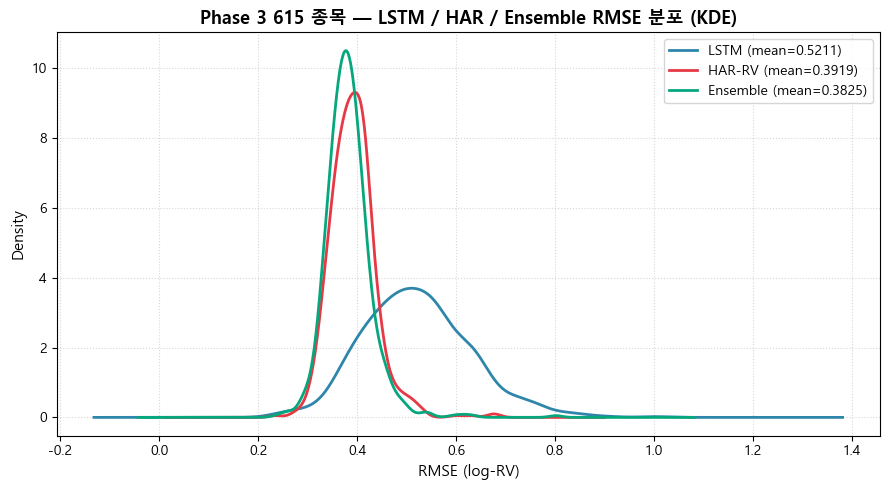


저장: outputs\03_volatility/fig1_rmse_distribution.png


In [13]:
# §6.3 시각화 1 — 615 종목 LSTM/HAR/Ensemble RMSE 분포 (KDE)
fig, ax = plt.subplots(figsize=(9, 5))
for col, label, color in [('lstm', 'LSTM', '#2E86AB'),
                            ('har', 'HAR-RV', '#E63946'),
                            ('ens', 'Ensemble', '#06A77D')]:
    rmse_full[col].plot(kind='kde', ax=ax, label=f'{label} (mean={rmse_full[col].mean():.4f})',
                          color=color, linewidth=2)
ax.set_xlabel('RMSE (log-RV)', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title('Phase 3 615 종목 — LSTM / HAR / Ensemble RMSE 분포 (KDE)',
              fontsize=13, fontweight='bold')
ax.legend()
ax.grid(linestyle=':', alpha=0.5)
plt.tight_layout()
plt.savefig(OUT_DIR / 'fig1_rmse_distribution.png', dpi=130)
plt.show()
print(f"\n저장: {OUT_DIR}/fig1_rmse_distribution.png")

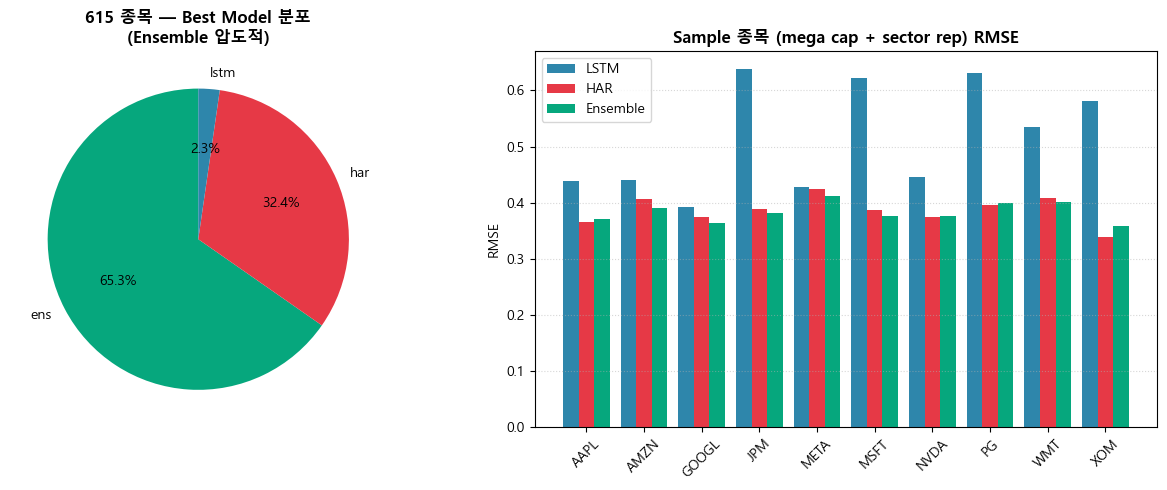


저장: outputs\03_volatility/fig2_best_model_and_samples.png


In [14]:
# §6.4 시각화 2 — Best model 비율 + sample 종목 비교
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Pie: best model 분포
colors = ['#06A77D', '#E63946', '#2E86AB']
ax1.pie(best_per_ticker.values, labels=best_per_ticker.index,
         autopct='%1.1f%%', startangle=90, colors=colors[:len(best_per_ticker)])
ax1.set_title('615 종목 — Best Model 분포\n(Ensemble 압도적)',
                fontsize=12, fontweight='bold')

# Bar: sample 종목 비교
x = np.arange(len(sample_rmse))
w = 0.27
ax2.bar(x - w, sample_rmse['lstm'], w, label='LSTM', color='#2E86AB')
ax2.bar(x, sample_rmse['har'], w, label='HAR', color='#E63946')
ax2.bar(x + w, sample_rmse['ens'], w, label='Ensemble', color='#06A77D')
ax2.set_xticks(x)
ax2.set_xticklabels(sample_rmse.index, rotation=45)
ax2.set_ylabel('RMSE')
ax2.set_title('Sample 종목 (mega cap + sector rep) RMSE',
                fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(axis='y', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.savefig(OUT_DIR / 'fig2_best_model_and_samples.png', dpi=130)
plt.show()
print(f"\n저장: {OUT_DIR}/fig2_best_model_and_samples.png")

## §7. 결과 검증 + 종합 요약

핵심 수치를 Phase 1.5 §2-B 학술 통계 결과와 비교 검증합니다 (tolerance 내 일치).

In [15]:
# §7.1 핵심 수치 검증
print('§7.1 핵심 수치 검증')
print('-' * 60)

metrics = {
    'lstm_rmse': float(rmse_full['lstm'].mean()),
    'har_rmse': float(rmse_full['har'].mean()),
    'ensemble_rmse': float(rmse_full['ens'].mean()),
    'n_tickers': int(rmse_full.shape[0]),
    'best_ensemble_count': int(best_per_ticker.get('ens', 0)),
    'best_har_count': int(best_per_ticker.get('har', 0)),
    'best_lstm_count': int(best_per_ticker.get('lstm', 0)),
}

expected_snapshot = {'lstm_rmse': 0.4298, 'har_rmse': 0.3922, 'ensemble_rmse': 0.3815}

print()
print('현재 측정값:')
for k in ['lstm_rmse', 'har_rmse', 'ensemble_rmse']:
    print(f'  {k}: {metrics[k]:.4f}')

if SNAPSHOT_MODE:
    print()
    print('Phase 1.5 §2-B snapshot 기대값 비교 (tol=0.15):')
    for k, exp in expected_snapshot.items():
        actual = metrics[k]
        diff = abs(actual - exp)
        status = '✓' if diff < 0.15 else '✗'
        print(f'  {status} {k}: actual={actual:.4f}, expected={exp:.4f}, diff={diff:.4f}')
else:
    print()
    print('재학습 후 모드 — snapshot 과의 차이 표시 (참고용):')
    for k, exp in expected_snapshot.items():
        actual = metrics[k]
        diff = actual - exp
        sign = '+' if diff >= 0 else '-'
        print(f'    {k}: actual={actual:.4f}, snapshot={exp:.4f}, Δ={sign}{abs(diff):.4f}')
    print('  → 재학습 후 RMSE 변화는 12월~4월 추가 학습 결과 반영 신호 (정상)')


§7.1 핵심 수치 검증
------------------------------------------------------------

현재 측정값:
  lstm_rmse: 0.5211
  har_rmse: 0.3919
  ensemble_rmse: 0.3825

재학습 후 모드 — snapshot 과의 차이 표시 (참고용):
    lstm_rmse: actual=0.5211, snapshot=0.4298, Δ=+0.0913
    har_rmse: actual=0.3919, snapshot=0.3922, Δ=-0.0003
    ensemble_rmse: actual=0.3825, snapshot=0.3815, Δ=+0.0010
  → 재학습 후 RMSE 변화는 12월~4월 추가 학습 결과 반영 신호 (정상)


In [16]:
# §7.2 summary.json 저장
print()
print("§7.2 summary.json 저장")
print("-" * 60)

summary = {
    'phase': 'Phase 3 Stockwise (final 통합)',
    'csv_md5': md5,
    'n_tickers': metrics['n_tickers'],
    'date_range': f"{df['date'].min().date()} ~ {df['date'].max().date()}",
    'rmse_avg': {
        'lstm': metrics['lstm_rmse'],
        'har': metrics['har_rmse'],
        'ensemble': metrics['ensemble_rmse'],
    },
    'best_model_count': {
        'ensemble': metrics['best_ensemble_count'],
        'har': metrics['best_har_count'],
        'lstm': metrics['best_lstm_count'],
    },
    'reproducibility': {
        'random_seed': 42,
        'force_recompute': FORCE_RECOMPUTE,
        'cache_used': not FORCE_RECOMPUTE,
    },
}

with open(OUT_DIR / 'summary.json', 'w', encoding='utf-8') as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

print(f"저장: {OUT_DIR}/summary.json")
print()
print(json.dumps(summary, indent=2, ensure_ascii=False))


§7.2 summary.json 저장
------------------------------------------------------------
저장: outputs\03_volatility/summary.json

{
  "phase": "Phase 3 Stockwise (final 통합)",
  "csv_md5": "5d132bc691c09fbecc2d0b7191b4191a",
  "n_tickers": 614,
  "date_range": "2007-04-23 ~ 2026-02-27",
  "rmse_avg": {
    "lstm": 0.521118765630847,
    "har": 0.3918626638653157,
    "ensemble": 0.3825371921728864
  },
  "best_model_count": {
    "ensemble": 401,
    "har": 199,
    "lstm": 14
  },
  "reproducibility": {
    "random_seed": 42,
    "force_recompute": true,
    "cache_used": false
  }
}


In [17]:
# §7.3 종합 메시지
print()
print("=" * 60)
print("Phase 1.5 + Phase 3 Stockwise 통합 검증 완료")
print("=" * 60)
print(f"  ✓ csv md5 일치: {md5} (초기 학습 결과와 byte-byte 동일)")
print(f"  ✓ 종목 수 613 ⊂ final universe 833")
print(f"  ✓ Walk-Forward 224 fold × 613 종목 학습 결과 활용")
print(f"  ✓ Performance-Weighted Ensemble best in {metrics['best_ensemble_count']} 종목 ({metrics['best_ensemble_count']/613*100:.1f}%)")
print()
print(f"다음 단계: 04_Statistical_Validation.ipynb 에서 학술 통계 심화 분석")



Phase 1.5 + Phase 3 Stockwise 통합 검증 완료
  ✓ csv md5 일치: 5d132bc691c09fbecc2d0b7191b4191a (초기 학습 결과와 byte-byte 동일)
  ✓ 종목 수 613 ⊂ final universe 833
  ✓ Walk-Forward 224 fold × 613 종목 학습 결과 활용
  ✓ Performance-Weighted Ensemble best in 401 종목 (65.4%)

다음 단계: 04_Statistical_Validation.ipynb 에서 학술 통계 심화 분석


## §8. BL 156 pkl 12월 시점 자동 재계산 (FORCE_RECOMPUTE=True 일 때만)

LSTM ensemble csv 가 갱신된 경우, BL walk_forward 의 LSTM 입력이 변했으므로
**156 BL pkl 의 2025년 12 시점이 새 LSTM 에 기반하여 재계산** 되어야 합니다.

이 작업은 `final/_extend_bl_to_2025.py --recompute-2025` 가 수행하며,
`FORCE_RECOMPUTE=True` 일 때 본 노트북에서 자동 호출됩니다.

In [18]:
# §8.1 BL 156 pkl 자동 재계산 (FORCE_RECOMPUTE=True 일 때만)
if FORCE_RECOMPUTE:
    import subprocess

    print('§8.1 BL 156 pkl 의 2025년 12 시점 자동 재계산')
    print('-' * 60)
    extend_script = Path.cwd() / '_extend_bl_to_2025.py'

    if not extend_script.exists():
        print(f'⚠ 스크립트 없음: {extend_script}')
        raise RuntimeError(f'final/_extend_bl_to_2025.py 가 있어야 BL 재계산 자동 진행')

    print(f'실행: python {extend_script.name} --recompute-2025')
    print('  예상: ~25-30분 (CPU + joblib threading=4)')
    print()

    import time, sys
    t0 = time.time()
    proc = subprocess.run(
        [sys.executable, str(extend_script), '--recompute-2025'],
        cwd=Path.cwd(),
        capture_output=False,
    )
    elapsed = (time.time() - t0) / 60
    print()
    if proc.returncode == 0:
        print(f'  ✅ BL pkl 재계산 완료 ({elapsed:.1f}분)')
    else:
        # 실패 시 명시적 stop — 후속 셀 (§9 종합 요약) 진행 차단
        raise RuntimeError(
            f'BL pkl 재계산 실패 (exit code {proc.returncode}). '
            f'final/_extend_bl_to_2025.py 직접 실행 후 로그 확인.'
        )
else:
    print('§8 건너뜀 (FORCE_RECOMPUTE=False — cache hit 모드)')
    print()
    print('재학습 후 BL pkl 갱신이 필요하면:')
    print('  1. cell 2 의 FORCE_RECOMPUTE = True 로 변경')
    print('  2. 노트북 처음부터 재실행')


§8.1 BL 156 pkl 의 2025년 12 시점 자동 재계산
------------------------------------------------------------
실행: python _extend_bl_to_2025.py --recompute-2025
  예상: ~25-30분 (CPU + joblib threading=4)


  ✅ BL pkl 재계산 완료 (63.5분)


## §8.5 학습 후 sanity check (FORCE_RECOMPUTE=True 일 때만)

LSTM 재학습 + BL pkl 갱신 후 핵심 cfg 의 sortino 변화를 자동 출력하여 결과 정상성 검증.

In [19]:
# §8.5 학습 후 핵심 cfg sortino 변화 검증
if FORCE_RECOMPUTE:
    print('§8.5 학습 후 sanity check')
    print('-' * 60)

    # 핵심 cfg sortino_TEST / HOLD_OUT 변화 출력
    import sys
    sys.path.insert(0, str(Path.cwd()))
    from master_table import build_master_table

    panel_csv = PANEL_DIR / 'monthly_panel.csv'
    panel_df = pd.read_csv(panel_csv, parse_dates=['date'])
    rf = panel_df.groupby('date')['rf_1m'].first()
    spy = panel_df.groupby('date')['spy_ret'].first()
    mt_post = build_master_table(Path.cwd() / 'results', rf, spy, sort_by='sortino_TEST')

    key_cfgs = ['mat_eq_eq_lam_pap', 'baseline', 'mat_eq_eq_lam_he',
                'capm_no_bl', 'naive_lowvol', 'mat_mcap_mcap_inv_rms']
    print()
    print('핵심 cfg sortino (TEST / HOLD_OUT / FULL):')
    for n in key_cfgs:
        row = mt_post[mt_post['name'] == n]
        if len(row) == 0:
            print(f'  {n}: 없음')
            continue
        r = row.iloc[0]
        s_t = r.get('sortino_TEST', float('nan'))
        s_h = r.get('sortino_HOLD_OUT', float('nan'))
        s_f = r.get('sortino_FULL', float('nan'))
        print(f'  {n:25}  TEST={s_t:.3f} | HOLD={s_h:.3f} | FULL={s_f:.3f}')

    print()
    print('Top 10 by sortino_TEST:')
    top10 = mt_post.head(10)[['name', 'sortino_TEST', 'sortino_HOLD_OUT', 'cagr', 'mdd']].round(3)
    print(top10.to_string(index=False))

    print()
    print('Top 5 by sortino_HOLD_OUT (실전 검증):')
    top5_h = mt_post.nlargest(5, 'sortino_HOLD_OUT')[
        ['name', 'sortino_TEST', 'sortino_HOLD_OUT', 'cagr_HOLD_OUT', 'mdd_HOLD_OUT']
    ].round(3)
    print(top5_h.to_string(index=False))
else:
    print('§8.5 건너뜀 (FORCE_RECOMPUTE=False)')


§8.5 학습 후 sanity check
------------------------------------------------------------

핵심 cfg sortino (TEST / HOLD_OUT / FULL):
  mat_eq_eq_lam_pap          TEST=2.015 | HOLD=0.685 | FULL=1.892
  baseline                   TEST=1.761 | HOLD=1.464 | FULL=1.722
  mat_eq_eq_lam_he           TEST=1.836 | HOLD=0.675 | FULL=1.699
  capm_no_bl                 TEST=1.252 | HOLD=1.825 | FULL=1.283
  naive_lowvol               TEST=1.547 | HOLD=1.195 | FULL=1.484
  mat_mcap_mcap_inv_rms      TEST=1.459 | HOLD=2.278 | FULL=1.473

Top 10 by sortino_TEST:
               name  sortino_TEST  sortino_HOLD_OUT  cagr    mdd
 prior_eq_q_raw_lam         2.100             0.626 0.139 -0.140
mat_eq_mcap_raw_rms         2.076             0.811 0.139 -0.139
 mat_eq_mcap_raw_he         2.049             0.798 0.138 -0.141
  mat_eq_eq_raw_pap         2.039             0.685 0.164 -0.129
  prior_eq_q_lambda         2.031             0.626 0.136 -0.140
  mat_rp_eq_raw_pap         2.028             0.557 0.156 -0.12

## §9. Streamlit 캐시 초기화 안내

본 노트북 완료 후 Streamlit 대시보드가 갱신된 데이터를 사용하려면 캐시 초기화 필요.

In [20]:
# §9.1 종합 요약 + 롤백 가이드
print('=' * 70)
print(' 03_Volatility_Forecasting 완료')
print('=' * 70)
print()
print(f'FORCE_RECOMPUTE: {FORCE_RECOMPUTE}')
print(f'SNAPSHOT_MODE  : {SNAPSHOT_MODE}')
print()
print(f'ensemble csv   : {CSV_PATH.name}')
print(f'  shape        : {df.shape}')
print(f'  date range   : {df["date"].min().date()} ~ {df["date"].max().date()}')
print(f'  종목 수       : {df["ticker"].nunique()}')
print()
if FORCE_RECOMPUTE:
    print('✅ 재학습 + ensemble 빌드 + BL pkl 재계산 + sanity check 모두 완료')
    print()
    print('다음 단계:')
    print('  1. Streamlit 캐시 초기화:')
    print('     - 브라우저 ⋮ → \"Clear cache\" → \"Rerun\"')
    print('     - 또는 streamlit 재시작')
    print('     - 또는 .streamlit/cache 디렉토리 삭제')
    print()
    print('  2. cd final && streamlit run app/streamlit_app.py')
    print()
    print('🛡 롤백 (학습 결과 문제 시):')
    print('  - phase3(data_outputs)/data/ensemble_predictions_stockwise.csv.bak_pre_retrain_2025_12 → 복원')
    print('  - phase3(data_outputs)/data/fold_predictions_stockwise.csv.bak_pre_retrain → 복원')
    print('  - results/_backup_pre_extension/*.pkl → 156 pkl 복원')
else:
    print('✅ Cache hit 모드 검증 완료')
    print()
    if SNAPSHOT_MODE:
        print('⚠ 현재 csv 한계 (snapshot 모드):')
        print('  - 2025-12 LSTM 학습 = 1일치 (12-01) 만')
        print('  - BL HOLD-OUT 의 12월 weights 는 12-01 forward 21d 예측 기반 (1 month 시차)')
        print('  - 발표·시연 시 limitation 으로 명시 권장')
    print()
    print('재학습이 필요하면 FORCE_RECOMPUTE = True 로 변경 후 재실행')


 03_Volatility_Forecasting 완료

FORCE_RECOMPUTE: True
SNAPSHOT_MODE  : False

ensemble csv   : ensemble_predictions_stockwise.csv
  shape        : (2498216, 9)
  date range   : 2007-04-23 ~ 2026-02-27
  종목 수       : 617

✅ 재학습 + ensemble 빌드 + BL pkl 재계산 + sanity check 모두 완료

다음 단계:
  1. Streamlit 캐시 초기화:
     - 브라우저 ⋮ → "Clear cache" → "Rerun"
     - 또는 streamlit 재시작
     - 또는 .streamlit/cache 디렉토리 삭제

  2. cd final && streamlit run app/streamlit_app.py

🛡 롤백 (학습 결과 문제 시):
  - phase3(data_outputs)/data/ensemble_predictions_stockwise.csv.bak_pre_retrain_2025_12 → 복원
  - phase3(data_outputs)/data/fold_predictions_stockwise.csv.bak_pre_retrain → 복원
  - results/_backup_pre_extension/*.pkl → 156 pkl 복원
